# OpenSlide WSI Benchmarking

Crawls `/workspace/emory_ts/emory_datasets/pathomics_data/` to collect a diverse set of whole slide images (diverse by format extension and by organ-system subdirectory), then benchmarks:
1. `openslide.OpenSlide()` — slide open time
2. `slide.read_region()` — time to read a 64×64 tile from level 0

Summary statistics are reported at the end.

In [1]:
import os
import shlex
import time
import random
import subprocess
from pathlib import Path
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed

import openslide
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", "{:.4f}".format)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f"openslide version: {openslide.__version__}")


openslide version: 1.4.3


## 1. Crawl and collect a diverse sample of WSI files

In [2]:
ROOT = Path("/workspace/emory_ts/emory_datasets/pathomics_data")

WSI_EXTENSIONS = {".svs", ".ndpi", ".scn", ".tif", ".tiff",
                  ".mrxs", ".vms", ".vmu", ".bif", ".qptiff"}

N_PER_ORGAN = 15   # files randomly sampled per organ system
MAX_TOTAL   = 120  # hard cap on total files to benchmark
MAX_DEPTH   = 7    # find -maxdepth (covers most dataset layouts)


def sample_organ(organ_dir: Path, n: int) -> list[Path]:
    """Randomly sample n WSI files from organ_dir using find | shuf."""
    name_preds = " -o ".join(f'-iname "*{ext}"' for ext in sorted(WSI_EXTENSIONS))
    cmd = (
        f"find {shlex.quote(str(organ_dir))} -maxdepth {MAX_DEPTH} -type f "
        f"\\( {name_preds} \\) 2>/dev/null | shuf -n {n}"
    )
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    return [Path(line) for line in result.stdout.splitlines() if line]


organ_dirs = sorted(d for d in ROOT.iterdir() if d.is_dir() and not d.name.startswith("."))
print(f"Sampling from {len(organ_dirs)} organ systems in parallel …", flush=True)

t0 = time.perf_counter()
all_files: list[Path] = []

with ThreadPoolExecutor(max_workers=len(organ_dirs)) as pool:
    futures = {pool.submit(sample_organ, d, N_PER_ORGAN): d.name for d in organ_dirs}
    for fut in as_completed(futures):
        organ = futures[fut]
        files = fut.result()
        print(f"  {organ:25s}  {len(files):>3d} files")
        all_files.extend(files)

discover_time = time.perf_counter() - t0
print(f"\n{len(all_files)} candidate files collected in {discover_time:.2f}s")


Sampling from 11 organ systems in parallel …
  opthal                       0 files
  hematology                  15 files
  cns                         15 files
  cvs                         15 files
  multi_system                15 files
  respiratory                 15 files
  head_and_neck               15 files
  msk                         15 files
  gu                          15 files
  gi                          15 files
  reproductive_obgyn          15 files

150 candidate files collected in 19.17s


In [3]:
random.shuffle(all_files)
selected = all_files[:MAX_TOTAL]

sel_df = pd.DataFrame(
    [{"path": str(p), "organ": p.relative_to(ROOT).parts[0],
      "ext": p.suffix.lower(), "size_mb": p.stat().st_size / 1e6}
     for p in selected]
)

print(f"Selected {len(sel_df)} files for benchmarking")
print("\nBreakdown by extension:")
display(sel_df.groupby("ext").agg(count=("path", "count"),
                                    mean_mb=("size_mb", "mean"),
                                    total_gb=("size_mb", lambda x: x.sum()/1e3)).round(3))
print("\nBreakdown by organ system:")
display(sel_df.groupby("organ").agg(count=("path", "count")).sort_values("count", ascending=False))


Selected 120 files for benchmarking

Breakdown by extension:


,count,mean_mb,total_gb
ext,,,
.mrxs,2,0.0300,0.0000
.ndpi,16,1541.2420,24.6600
.qptiff,1,720.5410,0.7210
.svs,61,1317.3030,80.3550
.tif,30,453.3160,13.5990
.tiff,10,317.2000,3.1720



Breakdown by organ system:


,count
organ,
head_and_neck,14
gi,14
msk,13
cvs,13
respiratory,12
gu,12
reproductive_obgyn,12
hematology,11
cns,10


## 2. Benchmark OpenSlide open + read_region

In [4]:
TILE_SIZE = (64, 64)   # (width, height)
LEVEL     = 0          # highest resolution
LOCATION  = (0, 0)     # top-left corner

results = []

for i, path in enumerate(selected):
    row = {
        "path"     : str(path),
        "filename" : path.name,
        "organ"    : path.relative_to(ROOT).parts[0],
        "ext"      : path.suffix.lower(),
        "size_mb"  : path.stat().st_size / 1e6,
        "open_s"   : None,
        "read_s"   : None,
        "vendor"   : None,
        "level_count": None,
        "width"    : None,
        "height"   : None,
        "error"    : None,
    }

    # ── open ──────────────────────────────────────────────────────────────
    try:
        t0 = time.perf_counter()
        slide = openslide.OpenSlide(str(path))
        row["open_s"] = time.perf_counter() - t0

        row["vendor"]      = slide.properties.get(openslide.PROPERTY_NAME_VENDOR, "unknown")
        row["level_count"] = slide.level_count
        row["width"], row["height"] = slide.dimensions

        # ── read_region ───────────────────────────────────────────────────
        # Clamp location so we never request outside the slide bounds
        loc_x = min(LOCATION[0], max(0, row["width"]  - TILE_SIZE[0]))
        loc_y = min(LOCATION[1], max(0, row["height"] - TILE_SIZE[1]))

        t0 = time.perf_counter()
        tile = slide.read_region((loc_x, loc_y), LEVEL, TILE_SIZE)
        row["read_s"] = time.perf_counter() - t0

        slide.close()

    except Exception as exc:
        row["error"] = f"{type(exc).__name__}: {exc}"

    results.append(row)

    if (i + 1) % 10 == 0 or (i + 1) == len(selected):
        print(f"  [{i+1}/{len(selected)}] last: {path.name[:60]}")

df = pd.DataFrame(results)
print(f"\nDone. {df['error'].isna().sum()} succeeded, {df['error'].notna().sum()} failed.")

  [10/120] last: 36 (2).tif
  [20/120] last: 162.tif
  [30/120] last: bx11 E1 draw.tif
  [40/120] last: Slide-0002623_TI06296 4001.svs
  [50/120] last: TCGA-33-6738-01Z-00-DX3.26deb8f3-f138-45e4-9765-f713030746e8
  [60/120] last: PIT_01_03479_01.tiff
  [70/120] last: 282075-30.svs
  [80/120] last: C3N-03223-22.svs


TIFFFetchNormalTag: Warning, ASCII value for tag "ImageDescription" contains null byte in value; value incorrectly truncated during reading due to implementation limitations.
TIFFFetchNormalTag: Warning, ASCII value for tag "ImageDescription" contains null byte in value; value incorrectly truncated during reading due to implementation limitations.
TIFFFetchNormalTag: Warning, ASCII value for tag "ImageDescription" contains null byte in value; value incorrectly truncated during reading due to implementation limitations.
TIFFFetchNormalTag: Warning, ASCII value for tag "ImageDescription" contains null byte in value; value incorrectly truncated during reading due to implementation limitations.
TIFFFetchNormalTag: Warning, ASCII value for tag "ImageDescription" contains null byte in value; value incorrectly truncated during reading due to implementation limitations.
TIFFFetchNormalTag: Warning, ASCII value for tag "ImageDescription" contains null byte in value; value incorrectly truncated 

  [90/120] last: TCGA-DK-A6B5-01Z-00-DX1.A1A01D61-DAA3-4172-8D69-FF0456190967
  [100/120] last: 15847-1.svs
  [110/120] last: A3E4BCA6-4F2B9BD1-A01-01-HE_13-4E9TJK15C.svs
  [120/120] last: TCGA-02-0048.svs

Done. 97 succeeded, 23 failed.


## 3. Failures

In [5]:
failures = df[df["error"].notna()][["filename", "ext", "organ", "size_mb", "error"]]
print(f"{len(failures)} failures:")
if len(failures):
    display(failures.reset_index(drop=True))
else:
    print("  (none)")

23 failures:


,filename,ext,organ,size_mb,error
0,LYM-WQEQWIKG.tif,.tif,gi,0.1522,OpenSlideUnsupportedFormatError: Unsupported or missing image file
1,TUM-AWYLIITI.tif,.tif,gi,0.1522,OpenSlideUnsupportedFormatError: Unsupported or missing image file
2,bx12 C3.tif,.tif,msk,5.5508,OpenSlideUnsupportedFormatError: Unsupported or missing image file
3,TUM-FTWAYYCE.tif,.tif,gi,0.1522,OpenSlideUnsupportedFormatError: Unsupported or missing image file
4,DEB-TCRGDVLI.tif,.tif,gi,0.1522,OpenSlideUnsupportedFormatError: Unsupported or missing image file
5,MUC-WKRALMKD.tif,.tif,gi,0.1522,OpenSlideUnsupportedFormatError: Unsupported or missing image file
6,TUM-ALVFSTFM.tif,.tif,gi,0.1522,OpenSlideUnsupportedFormatError: Unsupported or missing image file
7,PIT_01_06070_01.tiff,.tiff,multi_system,571.7991,OpenSlideUnsupportedFormatError: Unsupported or missing image file
8,BACK-MFPGNNFP.tif,.tif,gi,0.1498,OpenSlideUnsupportedFormatError: Unsupported or missing image file
9,bx11 E1 draw.tif,.tif,msk,5.5508,OpenSlideUnsupportedFormatError: Unsupported or missing image file


## 4. Summary statistics

In [6]:
good = df[df["error"].isna()].copy()

print("=" * 60)
print("OVERALL SUMMARY (successful slides only)")
print("=" * 60)

for col, label in [("open_s", "OpenSlide() open  (s)"),
                   ("read_s", "read_region 64×64 (s)")]:
    vals = good[col].dropna()
    print(f"\n{label}")
    print(f"  n       = {len(vals)}")
    print(f"  mean    = {vals.mean():.4f}")
    print(f"  std     = {vals.std():.4f}")
    print(f"  min     = {vals.min():.4f}")
    print(f"  p25     = {vals.quantile(0.25):.4f}")
    print(f"  median  = {vals.median():.4f}")
    print(f"  p75     = {vals.quantile(0.75):.4f}")
    print(f"  p95     = {vals.quantile(0.95):.4f}")
    print(f"  max     = {vals.max():.4f}")

OVERALL SUMMARY (successful slides only)

OpenSlide() open  (s)
  n       = 97
  mean    = 0.5436
  std     = 0.4283
  min     = 0.0659
  p25     = 0.3175
  median  = 0.4150
  p75     = 0.5060
  p95     = 1.7713
  max     = 1.8628

read_region 64×64 (s)
  n       = 97
  mean    = 0.0156
  std     = 0.0324
  min     = 0.0001
  p25     = 0.0005
  median  = 0.0008
  p75     = 0.0085
  p95     = 0.1023
  max     = 0.1367


In [7]:
print("\nSummary by file extension:")
ext_stats = (
    good.groupby("ext")[["open_s", "read_s", "size_mb"]]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(4)
)
display(ext_stats)

print("\nSummary by organ system:")
organ_stats = (
    good.groupby("organ")[["open_s", "read_s", "size_mb"]]
    .agg(["count", "mean", "median"])
    .round(4)
)
display(organ_stats)


Summary by file extension:


open_s                                    read_s                       \
         count   mean median    std    min    max  count   mean median    std   
ext                                                                             
.mrxs        2 0.2571 0.2571 0.1099 0.1794 0.3348      2 0.0172 0.0172 0.0242   
.ndpi       16 0.4577 0.4243 0.1738 0.2362 0.8118     16 0.0708 0.0788 0.0440   
.qptiff      1 0.5446 0.5446    NaN 0.5446 0.5446      1 0.0014 0.0014    NaN   
.svs        61 0.6362 0.4309 0.5058 0.0659 1.8628     61 0.0008 0.0006 0.0007   
.tif        10 0.3912 0.3764 0.0761 0.2278 0.4894     10 0.0102 0.0067 0.0097   
.tiff        7 0.2318 0.2402 0.0645 0.1105 0.2990      7 0.0275 0.0161 0.0334   

                      size_mb                                                   
           min    max   count      mean    median       std      min       max  
ext                                                                             
.mrxs   0.0001 0.0344       2    0.0298    0.0298    0.0094   0.0231    0.0364  
.ndpi   0.0053 0.1367      16 1541.2420 1341.7755 1168.0581 142.1135 4498.4182  
.qptiff 0.0014 0.0014       1  720.5406  720.5406       NaN 720.5406  720.5406  
.svs    0.0004 0.0038      61 1317.3031  812.0474 1403.8726  69.0132 6222.4769  
.tif    0.0008 0.0317      10 1356.7550  912.1132 1165.1244 279.3098 4141.6944  
.tiff   0.0010 0.1008       7  207.5632   88.3874  241.3922  29.8573  671.7236


Summary by organ system:


open_s               read_s               size_mb  \
                    count   mean median  count   mean median   count   
organ                                                                  
cns                    10 0.7728 0.3809     10 0.0009 0.0006      10   
cvs                    13 1.0679 1.1919     13 0.0208 0.0007      13   
gi                      1 0.4829 0.4829      1 0.0006 0.0006       1   
gu                     11 0.3307 0.3291     11 0.0293 0.0053      11   
head_and_neck          13 0.5703 0.4354     13 0.0208 0.0011      13   
hematology             11 0.4360 0.4735     11 0.0006 0.0006      11   
msk                     8 0.3897 0.4087      8 0.0007 0.0005       8   
multi_system            6 0.2280 0.2364      6 0.0152 0.0149       6   
reproductive_obgyn     12 0.4014 0.3585     12 0.0258 0.0130      12   
respiratory            12 0.4570 0.4538     12 0.0191 0.0014      12   

                                        
                        mean    median  
organ                                   
cns                 885.4235  472.2329  
cvs                 652.4284  520.6930  
gi                  951.9624  951.9624  
gu                  638.1948  412.9308  
head_and_neck      1669.7949 1743.4686  
hematology         3190.3527 2527.0619  
msk                 893.9465  731.3003  
multi_system        237.1808  118.3140  
reproductive_obgyn 1468.2724 1272.4191  
respiratory        1037.7838  793.3138

## 5. Visualisations

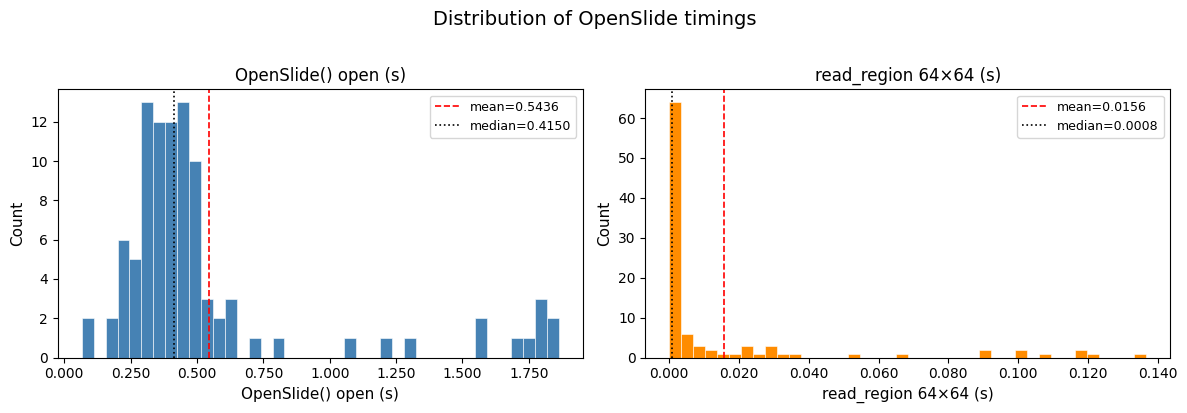

In [8]:
# ── Figure 1: histograms of open and read times ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, label, color in [
    (axes[0], "open_s", "OpenSlide() open (s)",    "steelblue"),
    (axes[1], "read_s", "read_region 64×64 (s)",   "darkorange"),
]:
    vals = good[col].dropna()
    ax.hist(vals, bins=40, color=color, edgecolor="white", linewidth=0.4)
    ax.axvline(vals.mean(),   color="red",   linestyle="--", linewidth=1.2, label=f"mean={vals.mean():.4f}")
    ax.axvline(vals.median(), color="black", linestyle=":",  linewidth=1.2, label=f"median={vals.median():.4f}")
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_title(label, fontsize=12)
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))

fig.suptitle("Distribution of OpenSlide timings", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_94819/4003162571.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=exts,
/tmp/ipykernel_94819/4003162571.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=exts,


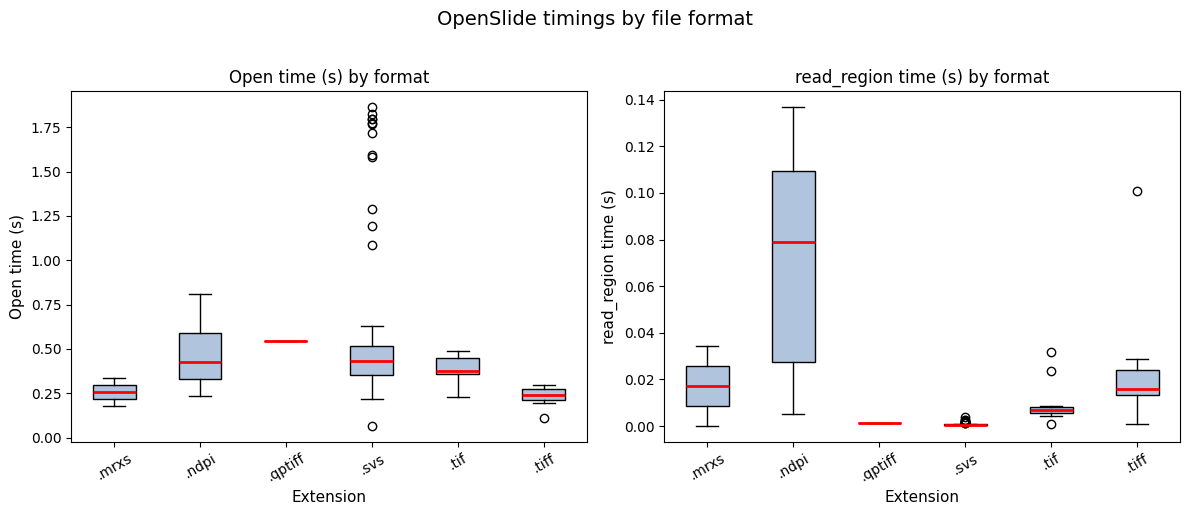

In [9]:
# ── Figure 2: box plots by file extension ────────────────────────────────
exts = sorted(good["ext"].unique())
fig, axes = plt.subplots(1, 2, figsize=(max(8, len(exts) * 2), 5))

for ax, col, label in [
    (axes[0], "open_s", "Open time (s)"),
    (axes[1], "read_s", "read_region time (s)"),
]:
    data = [good.loc[good["ext"] == e, col].dropna().values for e in exts]
    bp = ax.boxplot(data, patch_artist=True, labels=exts,
                    medianprops=dict(color="red", linewidth=2))
    for patch in bp["boxes"]:
        patch.set_facecolor("lightsteelblue")
    ax.set_xlabel("Extension", fontsize=11)
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(f"{label} by format", fontsize=12)
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("OpenSlide timings by file format", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

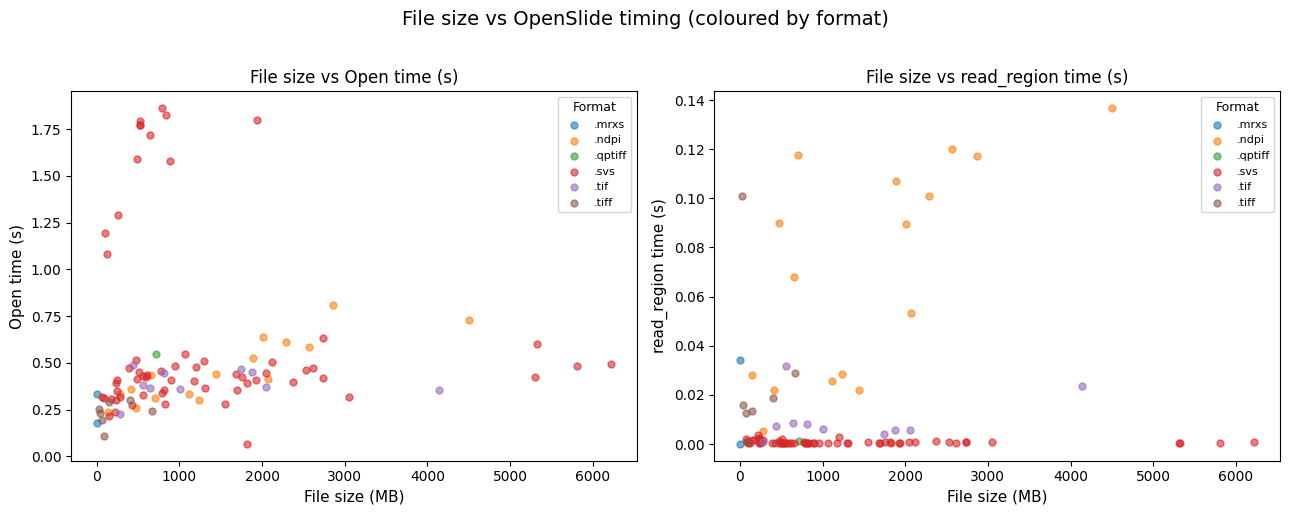

In [10]:
# ── Figure 3: scatter — file size vs open time, coloured by format ────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = plt.cm.tab10.colors
ext_color = {e: colors[i % len(colors)] for i, e in enumerate(exts)}

for ax, col, label in [
    (axes[0], "open_s", "Open time (s)"),
    (axes[1], "read_s", "read_region time (s)"),
]:
    for ext in exts:
        sub = good[good["ext"] == ext]
        ax.scatter(sub["size_mb"], sub[col],
                   alpha=0.6, s=25, label=ext, color=ext_color[ext])
    ax.set_xlabel("File size (MB)", fontsize=11)
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(f"File size vs {label}", fontsize=12)
    ax.legend(title="Format", fontsize=8, title_fontsize=9)

fig.suptitle("File size vs OpenSlide timing (coloured by format)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

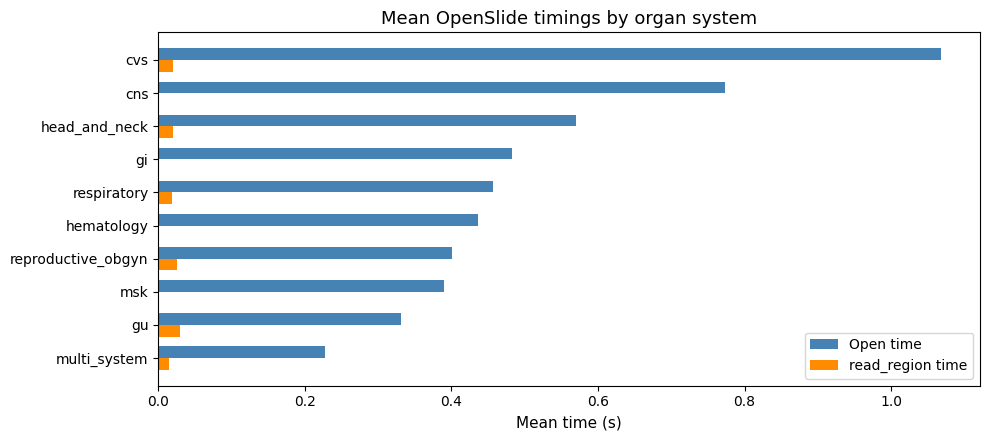

In [11]:
# ── Figure 4: mean timings by organ system ───────────────────────────────
organ_means = good.groupby("organ")[["open_s", "read_s"]].mean().sort_values("open_s", ascending=True)

fig, ax = plt.subplots(figsize=(10, max(4, len(organ_means) * 0.45)))
y = np.arange(len(organ_means))
bar_h = 0.35

ax.barh(y + bar_h/2, organ_means["open_s"],  height=bar_h, label="Open time",        color="steelblue")
ax.barh(y - bar_h/2, organ_means["read_s"],  height=bar_h, label="read_region time", color="darkorange")
ax.set_yticks(y)
ax.set_yticklabels(organ_means.index, fontsize=10)
ax.set_xlabel("Mean time (s)", fontsize=11)
ax.set_title("Mean OpenSlide timings by organ system", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 6. Detailed results table (fastest / slowest)

In [12]:
cols_show = ["filename", "organ", "ext", "size_mb", "vendor",
             "level_count", "width", "height", "open_s", "read_s"]

print("10 FASTEST open times:")
display(good[cols_show].nsmallest(10, "open_s").reset_index(drop=True))

print("\n10 SLOWEST open times:")
display(good[cols_show].nlargest(10, "open_s").reset_index(drop=True))

print("\n10 FASTEST read_region times:")
display(good[cols_show].nsmallest(10, "read_s").reset_index(drop=True))

print("\n10 SLOWEST read_region times:")
display(good[cols_show].nlargest(10, "read_s").reset_index(drop=True))

10 FASTEST open times:


,filename,organ,ext,size_mb,vendor,level_count,width,height,open_s,read_s
0,18605-0.svs,hematology,.svs,1822.2849,aperio,4.0000,83664.0000,90333.0000,0.0659,0.0005
1,PIT_01_01764_01.tiff,multi_system,.tiff,88.3874,generic-tiff,1.0000,63803.0000,18338.0000,0.1105,0.0010
2,2021BNB-HE 017.mrxs,cvs,.mrxs,0.0364,mirax,9.0000,82626.0000,195221.0000,0.1794,0.0344
3,PIT_01_02717_01.tiff,multi_system,.tiff,69.4495,generic-tiff,1.0000,25920.0000,17840.0000,0.1935,0.0128
4,TCGA-06-5418.svs,cns,.svs,150.2989,aperio,4.0000,79617.0000,36059.0000,0.2173,0.0017
5,2353301811.tif,respiratory,.tif,279.3098,generic-tiff,8.0000,21912.0000,29543.0000,0.2278,0.0008
6,PIT_01_01974_01.tiff,multi_system,.tiff,41.8871,generic-tiff,1.0000,27914.0000,8318.0000,0.2326,0.0161
7,11_26609_020_004 A1_8 PAS.ndpi,gu,.ndpi,142.1135,hamamatsu,12.0000,69632.0000,36864.0000,0.2362,0.0280
8,3311001748.svs,reproductive_obgyn,.svs,222.1001,aperio,3.0000,31871.0000,31009.0000,0.2363,0.0038
9,PIT_01_03479_01.tiff,multi_system,.tiff,671.7236,generic-tiff,1.0000,41871.0000,42133.0000,0.2402,0.0290



10 SLOWEST open times:


,filename,organ,ext,size_mb,vendor,level_count,width,height,open_s,read_s
0,5FDF59A2-82CC6F69-A01-01-HE_13-4LKSJK1T4.svs,cvs,.svs,785.7296,aperio,3.0000,170234.0000,48444.0000,1.8628,0.0004
1,04536432-b8f4-d6f9-2a69-fa5b8f5954dd_105140.svs,cns,.svs,837.5648,aperio,4.0000,76143.0000,78328.0000,1.8236,0.0004
2,12db9f76-375f-6fd0-0a04-45e8abeb9a0f_113020.svs,cns,.svs,1940.8803,aperio,4.0000,151044.0000,75944.0000,1.7965,0.0004
3,42FD5740-DE53E7FE-A01-03-C4d_IHC-0GBUJK1R4.svs,cvs,.svs,518.0671,aperio,4.0000,76746.0000,70338.0000,1.7940,0.0004
4,1B7B4E2D-B0A140F6-A01-01-HE_13-85AUJK1PM.svs,cvs,.svs,520.6930,aperio,3.0000,129412.0000,36696.0000,1.7740,0.0005
5,1_10_130156.svs,cns,.svs,520.8048,aperio,3.0000,51308.0000,54884.0000,1.7707,0.0004
6,0D3EB9C0-47F08AE3-A01-01-HE_13-4EORJK1H9.svs,cvs,.svs,649.9461,aperio,3.0000,131420.0000,48991.0000,1.7176,0.0004
7,A3E4BCA6-4F2B9BD1-A01-01-HE_13-4E9TJK15C.svs,cvs,.svs,482.4852,aperio,3.0000,116757.0000,34725.0000,1.5920,0.0004
8,BCM_MusPriT_584006_115342.svs,head_and_neck,.svs,884.3940,aperio,4.0000,80956.0000,66480.0000,1.5825,0.0004
9,74D02771-B427674E-A01-02-HE_45-762TJK1E3.svs,cvs,.svs,256.0459,aperio,3.0000,75465.0000,31709.0000,1.2882,0.0007



10 FASTEST read_region times:


,filename,organ,ext,size_mb,vendor,level_count,width,height,open_s,read_s
0,1096_tp2.mrxs,hematology,.mrxs,0.0231,mirax,10.0000,272128.0000,294144.0000,0.3348,0.0001
1,cb8e9525-9b49-26a1-048e-c41b9db9eadf_140737.svs,head_and_neck,.svs,126.9337,aperio,3.0000,26622.0000,31579.0000,1.0845,0.0004
2,1_10_130156.svs,cns,.svs,520.8048,aperio,3.0000,51308.0000,54884.0000,1.7707,0.0004
3,5FDF59A2-82CC6F69-A01-01-HE_13-4LKSJK1T4.svs,cvs,.svs,785.7296,aperio,3.0000,170234.0000,48444.0000,1.8628,0.0004
4,42FD5740-DE53E7FE-A01-03-C4d_IHC-0GBUJK1R4.svs,cvs,.svs,518.0671,aperio,4.0000,76746.0000,70338.0000,1.7940,0.0004
5,A3E4BCA6-4F2B9BD1-A01-01-HE_13-4E9TJK15C.svs,cvs,.svs,482.4852,aperio,3.0000,116757.0000,34725.0000,1.5920,0.0004
6,04536432-b8f4-d6f9-2a69-fa5b8f5954dd_105140.svs,cns,.svs,837.5648,aperio,4.0000,76143.0000,78328.0000,1.8236,0.0004
7,6FAB698D-CF76234D-A01-03-C4d_IHC-F7USJK1AA.svs,cvs,.svs,100.7924,aperio,3.0000,24046.0000,23239.0000,1.1919,0.0004
8,0D3EB9C0-47F08AE3-A01-01-HE_13-4EORJK1H9.svs,cvs,.svs,649.9461,aperio,3.0000,131420.0000,48991.0000,1.7176,0.0004
9,12db9f76-375f-6fd0-0a04-45e8abeb9a0f_113020.svs,cns,.svs,1940.8803,aperio,4.0000,151044.0000,75944.0000,1.7965,0.0004



10 SLOWEST read_region times:


,filename,organ,ext,size_mb,vendor,level_count,width,height,open_s,read_s
0,3 577-1522_1.1 - 2023-09-25 13.10.02.ndpi,head_and_neck,.ndpi,4498.4182,hamamatsu,9.0000,203520.0000,105984.0000,0.7280,0.1367
1,HS19-33121 2B .ndpi,respiratory,.ndpi,2565.3439,hamamatsu,9.0000,122880.0000,96768.0000,0.5864,0.1202
2,12_26609_001_501 L06 HE.ndpi,gu,.ndpi,704.7795,hamamatsu,10.0000,138880.0000,40960.0000,0.3113,0.1175
3,1199 LV .ndpi,cvs,.ndpi,2862.9708,hamamatsu,9.0000,165120.0000,78336.0000,0.8118,0.1171
4,CCF OP 97 - 2019-03-19 12.30.11.ndpi,head_and_neck,.ndpi,1884.4221,hamamatsu,11.0000,179200.0000,64512.0000,0.5260,0.1069
5,577-1391_2.1B - 2023-12-07 18.42.27.ndpi,reproductive_obgyn,.ndpi,2293.0929,hamamatsu,9.0000,172800.0000,71424.0000,0.6102,0.1011
6,slide_H&E_0.tiff,reproductive_obgyn,.tiff,29.8573,generic-tiff,6.0000,15640.0000,68255.0000,0.2547,0.1008
7,12_26609_022_013 L2 TRI.ndpi,gu,.ndpi,473.2076,hamamatsu,11.0000,81920.0000,50176.0000,0.2600,0.0901
8,HS16-9692 1A .ndpi,respiratory,.ndpi,2015.4498,hamamatsu,9.0000,103680.0000,94464.0000,0.6384,0.0896
9,1385 LV .ndpi,cvs,.ndpi,657.8483,hamamatsu,9.0000,84480.0000,36864.0000,0.4337,0.0681


In [13]:
# Save results to CSV alongside this notebook
out_csv = Path(__file__).parent / "openslide_benchmark_results.csv" if "__file__" in dir() \
          else Path("openslide_benchmark_results.csv")
df.to_csv(out_csv, index=False)
print(f"Results saved to: {out_csv.resolve()}")

Results saved to: /opt/PatchSorter/prototyping/agent_benchmarks/openslide_benchmark_results.csv
